In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [13]:
df = pd.read_csv('Stress_Dataset.csv')

In [14]:
df

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,0,21,3,4,2,3,5,1,5,4,...,2,3,3,3,4,1,2,2,2,Eustress (Positive Stress) - Stress that motiv...
839,1,19,3,2,1,2,2,1,2,3,...,1,1,1,3,2,1,2,3,1,No Stress - Currently experiencing minimal to ...
840,1,19,4,4,3,4,3,2,2,3,...,2,2,2,2,3,1,4,5,3,Eustress (Positive Stress) - Stress that motiv...
841,0,20,5,4,3,4,3,4,4,4,...,2,2,1,4,3,5,4,5,1,Eustress (Positive Stress) - Stress that motiv...


In [15]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['Which type of stress do you primarily experience?'])
target_names = le.classes_

In [16]:
X = df.drop(['Which type of stress do you primarily experience?', 'target'], axis=1)
y = df['target']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [21]:
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.01, random_state=42)

In [22]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

Ridge(random_state=42)

In [23]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.01, random_state=42)

In [25]:
models_data = {
    'Linear Regression': lr,
    'L1 (Lasso)': lasso,
    'L2 (Ridge)': ridge,
    'Elastic Net': elastic
}

print("\nModel Performance ($R^2$ Score):")
for name, model in models_data.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    non_zero = np.sum(np.abs(model.coef_) > 1e-10)
    print(f"{name:18} - Train: {train_score:.4f}, Test: {test_score:.4f}, Non-zero Coefs: {non_zero}")


Model Performance ($R^2$ Score):
Linear Regression  - Train: 0.4697, Test: 0.3750, Non-zero Coefs: 25
L1 (Lasso)         - Train: 0.4603, Test: 0.3822, Non-zero Coefs: 23
L2 (Ridge)         - Train: 0.4697, Test: 0.3751, Non-zero Coefs: 25
Elastic Net        - Train: 0.4671, Test: 0.3810, Non-zero Coefs: 24


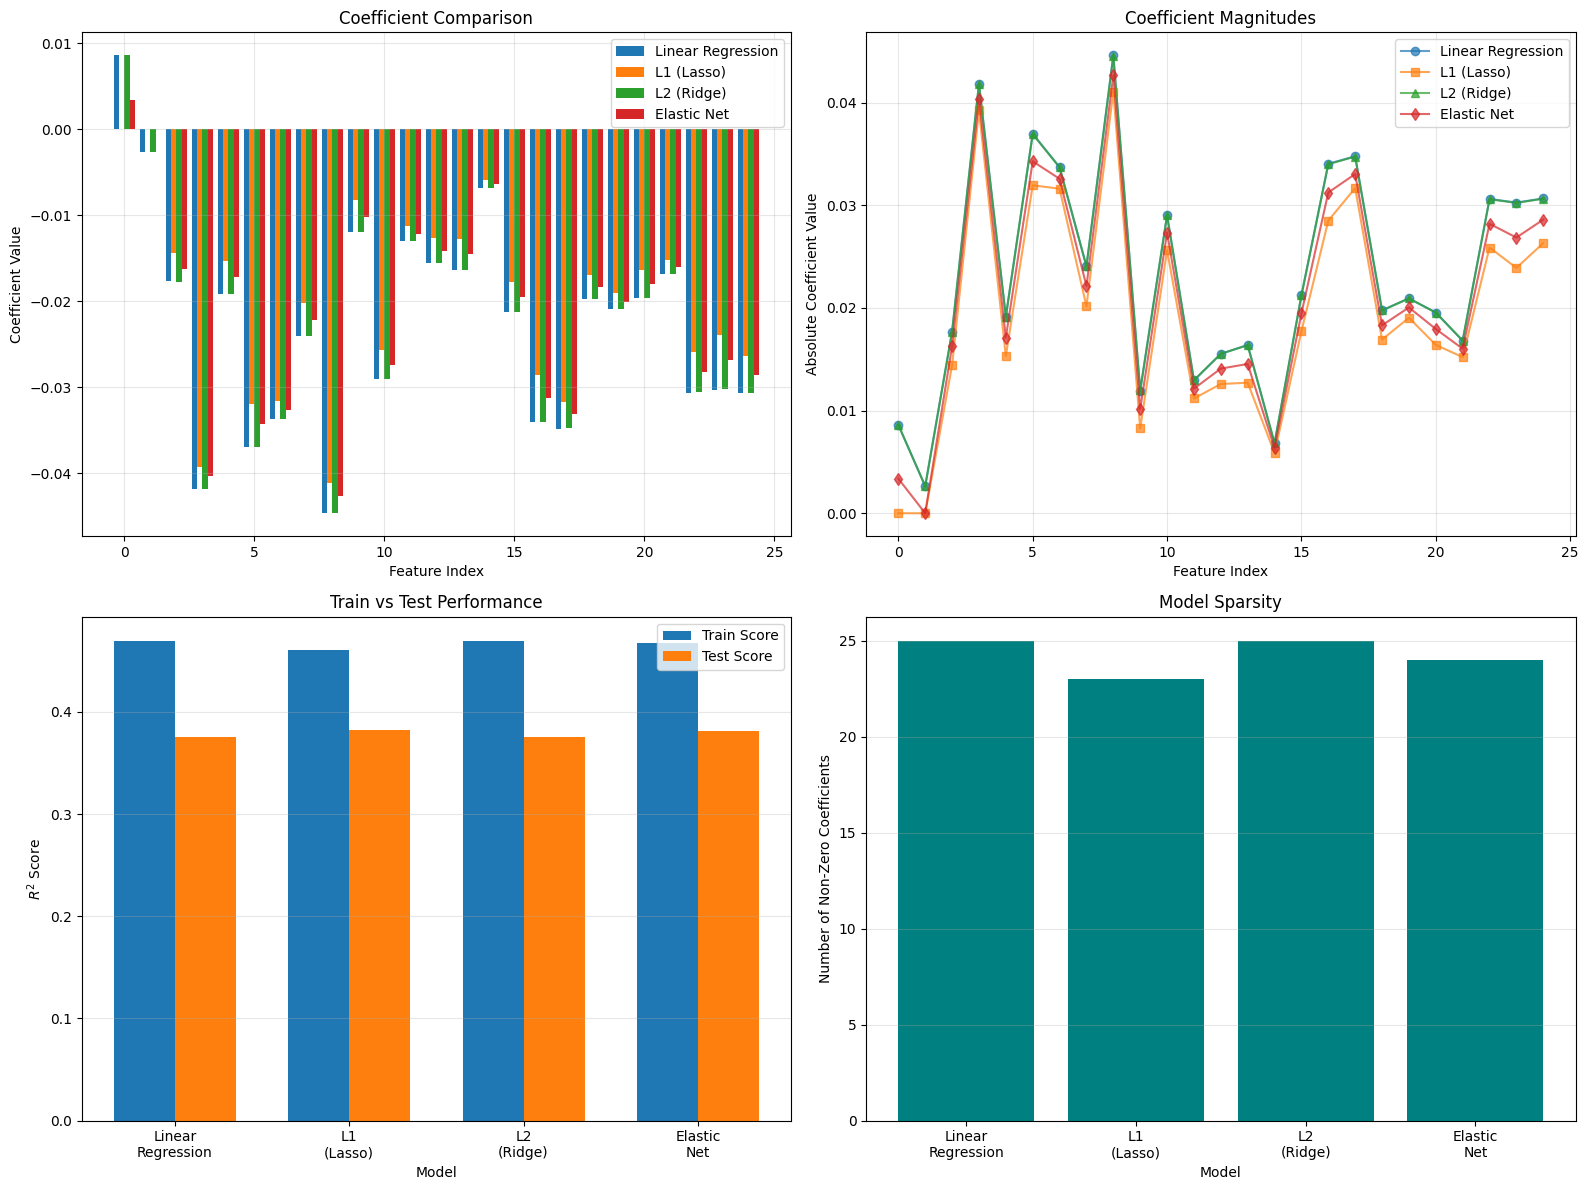

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
x_pos = np.arange(len(X.columns))
width = 0.2
ax1.bar(x_pos - 1.5*width, lr.coef_, width, label='Linear Regression')
ax1.bar(x_pos - 0.5*width, lasso.coef_, width, label='L1 (Lasso)')
ax1.bar(x_pos + 0.5*width, ridge.coef_, width, label='L2 (Ridge)')
ax1.bar(x_pos + 1.5*width, elastic.coef_, width, label='Elastic Net')
ax1.set_xlabel('Feature Index')
ax1.set_ylabel('Coefficient Value')
ax1.set_title('Coefficient Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(np.abs(lr.coef_), marker='o', label='Linear Regression', alpha=0.7)
ax2.plot(np.abs(lasso.coef_), marker='s', label='L1 (Lasso)', alpha=0.7)
ax2.plot(np.abs(ridge.coef_), marker='^', label='L2 (Ridge)', alpha=0.7)
ax2.plot(np.abs(elastic.coef_), marker='d', label='Elastic Net', alpha=0.7)
ax2.set_xlabel('Feature Index')
ax2.set_ylabel('Absolute Coefficient Value')
ax2.set_title('Coefficient Magnitudes')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
model_names = ['Linear\nRegression', 'L1\n(Lasso)', 'L2\n(Ridge)', 'Elastic\nNet']
train_scores = [m.score(X_train_scaled, y_train) for m in models_data.values()]
test_scores = [m.score(X_test_scaled, y_test) for m in models_data.values()]
x_pos_m = np.arange(len(model_names))
ax3.bar(x_pos_m - 0.175, train_scores, 0.35, label='Train Score')
ax3.bar(x_pos_m + 0.175, test_scores, 0.35, label='Test Score')
ax3.set_xlabel('Model')
ax3.set_ylabel('$R^2$ Score')
ax3.set_title('Train vs Test Performance')
ax3.set_xticks(x_pos_m)
ax3.set_xticklabels(model_names)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1, 1]
non_zero_counts = [np.sum(np.abs(m.coef_) > 1e-10) for m in models_data.values()]
ax4.bar(model_names, non_zero_counts, color='teal')
ax4.set_xlabel('Model')
ax4.set_ylabel('Number of Non-Zero Coefficients')
ax4.set_title('Model Sparsity')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [31]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
lasso_scores, ridge_scores, elastic_scores = [], [], []
lasso_sparsity, ridge_sparsity, elastic_sparsity = [], [], []

for a in alphas:
    la = Lasso(alpha=a, random_state=42).fit(X_train_scaled, y_train)
    lasso_scores.append(la.score(X_test_scaled, y_test))
    lasso_sparsity.append(np.sum(np.abs(la.coef_) > 1e-10))

    ri = Ridge(alpha=a, random_state=42).fit(X_train_scaled, y_train)
    ridge_scores.append(ri.score(X_test_scaled, y_test))
    ridge_sparsity.append(np.sum(np.abs(ri.coef_) > 1e-10))

    en = ElasticNet(alpha=a, l1_ratio=0.5, random_state=42).fit(X_train_scaled, y_train)
    elastic_scores.append(en.score(X_test_scaled, y_test))
    elastic_sparsity.append(np.sum(np.abs(en.coef_) > 1e-10))

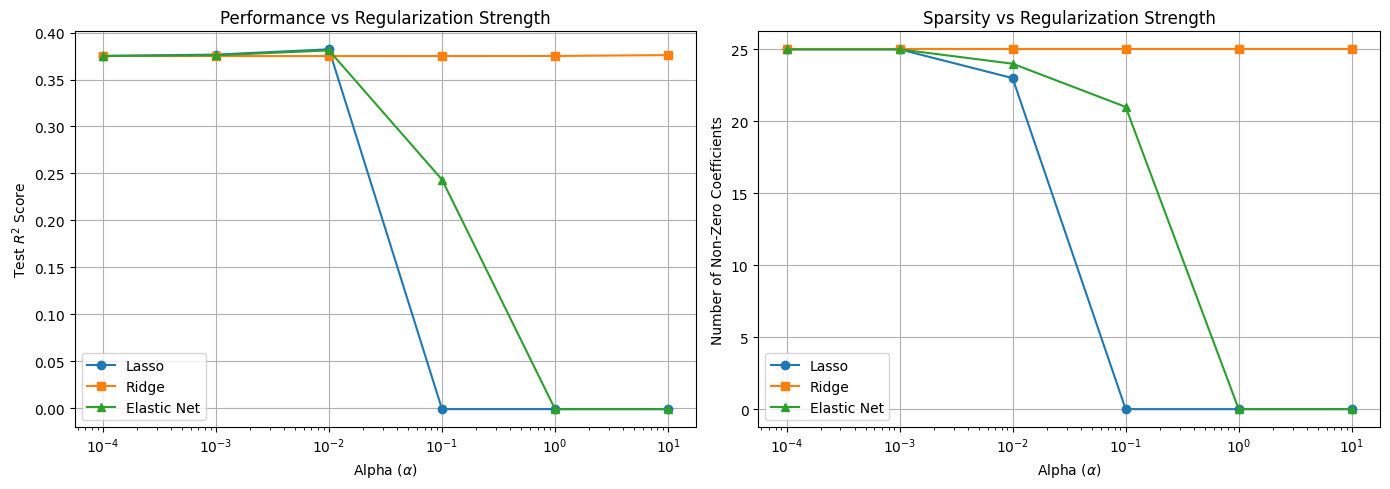

In [32]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

axes2[0].plot(alphas, lasso_scores, marker='o', label='Lasso')
axes2[0].plot(alphas, ridge_scores, marker='s', label='Ridge')
axes2[0].plot(alphas, elastic_scores, marker='^', label='Elastic Net')
axes2[0].set_xscale('log')
axes2[0].set_xlabel(r'Alpha ($\alpha$)')
axes2[0].set_ylabel('Test $R^2$ Score')
axes2[0].set_title('Performance vs Regularization Strength')
axes2[0].legend()
axes2[0].grid(True)

axes2[1].plot(alphas, lasso_sparsity, marker='o', label='Lasso')
axes2[1].plot(alphas, ridge_sparsity, marker='s', label='Ridge')
axes2[1].plot(alphas, elastic_sparsity, marker='^', label='Elastic Net')
axes2[1].set_xscale('log')
axes2[1].set_xlabel(r'Alpha ($\alpha$)')
axes2[1].set_ylabel('Number of Non-Zero Coefficients')
axes2[1].set_title('Sparsity vs Regularization Strength')
axes2[1].legend()
axes2[1].grid(True)

plt.tight_layout()
plt.show()